# Additional results

Supporting figures for the appendix. Same setup and metrics as `report_analysis.ipynb`.

## Setup

In [1]:
import re, time, itertools, logging, warnings
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse, stats
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import normalize
from gensim.models import Word2Vec
from gensim.test.utils import datapath
import gensim.downloader as api
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
logging.getLogger("gensim").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 100, "savefig.dpi": 200, "axes.titleweight": "bold",
                     "axes.titlesize": 11, "axes.labelsize": 10})

SEED = 42
DATA_FILE = "emotion_multigenre_corpus_setences.txt"
CLAUSE_FILE = "emotion_multigenre_corpus_clauses.txt"
STOPLIST = "mallet_en_stoplist.txt"
GENRES = ["newsheadline", "moviereview", "blog"]
K, K_MAX = 10, 50
N_EVAL_PER_GENRE = 300
N_REPEATS = 30
N_BOOT = 2000
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

METHODS = ["one-hot", "tf-idf", "word2vec"]
REF = "GloVe (pretrained)"
ALL_M = METHODS + [REF]
MC = {"one-hot": "#4C72B0", "tf-idf": "#DD8452", "word2vec": "#55A868", REF: "#9A9A9A"}
GC = {"newsheadline": "#8172B3", "moviereview": "#C44E52", "blog": "#3A9BBF"}
POLARITY = {"joy": "positive", "trust": "positive", "anger": "negative", "disgust": "negative",
            "fear": "negative", "sadness": "negative", "noemotion": "neutral"}
P_LIST = ["positive", "negative", "neutral", "ambiguous"]

def save(fig, name):
    # save a figure to figures/
    fig.savefig(FIG_DIR / f"{name}.png", bbox_inches="tight", facecolor="white")

In [2]:
def load_corpus(path):
    # last three tab-separated fields are text, emotion, genre
    rows = []
    with open(path, encoding="utf-8") as f:
        for line in f:
            parts = line.rstrip("\n").split("\t")
            if len(parts) >= 4:
                rows.append({"text": parts[-3].strip(), "emotion": parts[-2], "genre": parts[-1]})
    return pd.DataFrame(rows)

with open(STOPLIST, encoding="utf-8") as f:
    STOPWORDS = set(w.strip() for w in f if w.strip())
TOKEN_RE = re.compile(r"[a-z]+(?:'[a-z]+)?")
PTB_BRACKETS = re.compile(r"-[LR][RSC]B-")

def tokenize(text):
    # same preprocessing as the main notebook
    return [t for t in TOKEN_RE.findall(PTB_BRACKETS.sub(" ", text).lower())
            if t not in STOPWORDS and len(t) > 1 and "'" not in t]

df = load_corpus(DATA_FILE)
df["tokens"] = df.text.apply(tokenize)
df = df[df.tokens.str.len() > 0].drop_duplicates(subset="text").reset_index(drop=True)
df["n_tok"] = df.tokens.str.len()
df["polarity"] = df.emotion.map(POLARITY).fillna("ambiguous")
N = len(df)

E_LIST = sorted(df.emotion.unique())
GENRE_BASE = df.genre.value_counts(normalize=True).reindex(GENRES)
COND_POL = pd.crosstab(df.genre, df.polarity, normalize="index").reindex(index=GENRES, columns=P_LIST).fillna(0).to_numpy()
COND_EMO = pd.crosstab(df.genre, df.emotion, normalize="index").reindex(index=GENRES, columns=E_LIST).fillna(0).to_numpy()
MR = GENRES.index("moviereview")
POS, NEG = P_LIST.index("positive"), P_LIST.index("negative")
pn = df[(df.genre == "moviereview") & df.polarity.isin(["positive", "negative"])].polarity.value_counts(normalize=True)
MR_CHANCE = float((pn ** 2).sum())
print(N, "sentences")

16822 sentences


In [3]:
identity = lambda x: x

def l2(X):
    # row-normalize so cosine = dot product
    return normalize(X) if sparse.issparse(X) else normalize(np.asarray(X, dtype=np.float64))

def enc_onehot(tl):
    # binary bag of words
    return CountVectorizer(analyzer=identity, binary=True).fit_transform(tl)

def enc_tfidf(tl, fit_on=None):
    # tf-idf, optionally fitted on a different set of sentences
    vec = TfidfVectorizer(analyzer=identity).fit(fit_on if fit_on is not None else tl)
    return vec.transform(tl), vec

def train_w2v(tl, seed=SEED, epochs=None):
    # skip-gram Word2Vec, more epochs for small corpora
    n = len(tl)
    if epochs is None:
        epochs = 50 if n < 1000 else (30 if n < 5000 else 20)
    return Word2Vec(sentences=tl, vector_size=100, window=5, min_count=1, sg=1,
                    epochs=epochs, workers=1, seed=seed)

def mean_vectors(tl, kv, dim=100):
    # sentence vector = mean of known word vectors
    X = np.zeros((len(tl), dim))
    for i, toks in enumerate(tl):
        v = [kv[w] for w in toks if w in kv.key_to_index]
        if v:
            X[i] = np.mean(v, axis=0)
    return X

TL = df.tokens.tolist()
X_oh = enc_onehot(TL)
X_tf, TFVEC = enc_tfidf(TL)
W2V_FULL = train_w2v(TL)
GLOVE = api.load("glove-wiki-gigaword-100")

FULL = {"one-hot": l2(X_oh), "tf-idf": l2(X_tf),
        "word2vec": l2(mean_vectors(TL, W2V_FULL.wv)), REF: l2(mean_vectors(TL, GLOVE))}

In [4]:
def pick_queries(frame, n=3, min_tokens=3, seed=SEED):
    # n random queries per genre (same rule as the main notebook)
    picks = []
    for g in [g for g in GENRES if g in set(frame.genre)]:
        pool = frame[(frame.genre == g) & (frame.tokens.str.len() >= min_tokens)]
        picks += pool.sample(n, random_state=seed).index.tolist()
    return picks

def topk_search(mats, q_idx, k=K_MAX, chunk=128):
    # top-k neighbours per query and method, plus how many candidates tie with the 10th score
    q_idx = np.asarray(q_idx)
    out = {}
    for m, X in mats.items():
        n = X.shape[0]
        kk = min(k, n - 1)
        idx = np.empty((len(q_idx), kk), dtype=np.int64)
        sc = np.empty((len(q_idx), kk))
        tied = np.empty(len(q_idx), dtype=np.int64)
        for s in range(0, len(q_idx), chunk):
            qs = q_idx[s:s + chunk]
            sim = X[qs] @ X.T
            sim = sim.toarray() if sparse.issparse(sim) else np.asarray(sim)
            sim = sim.astype(np.float64)
            sim[np.arange(len(qs)), qs] = -np.inf
            order = np.argsort(-sim, axis=1, kind="stable")[:, :kk]
            top = np.take_along_axis(sim, order, axis=1)
            idx[s:s + len(qs)], sc[s:s + len(qs)] = order, top
            kth = top[:, min(K, kk) - 1][:, None]
            tied[s:s + len(qs)] = np.isclose(sim, kth, rtol=0, atol=1e-9).sum(axis=1)
        out[m] = {"idx": idx, "score": sc, "tied_at_k": tied}
    return out

def make_meta(frame, glove_mat):
    # labels and GloVe vectors needed for the metrics
    return {"g": pd.Categorical(frame.genre, categories=GENRES).codes,
            "p": pd.Categorical(frame.polarity, categories=P_LIST).codes,
            "e": pd.Categorical(frame.emotion, categories=E_LIST).codes,
            "toks": [set(t) for t in frame.tokens], "ntok": frame.n_tok.to_numpy(), "glove": glove_mat}

def per_query_metrics(res, q_idx, meta, k=K, rand_n=500, seed=SEED):
    # one row per query and method with all metrics at k
    q_idx = np.asarray(q_idx)
    n = len(meta["g"])
    gq, pq, eq = meta["g"][q_idx], meta["p"][q_idx], meta["e"][q_idx]
    Gv = meta["glove"]
    if n - 1 <= rand_n:
        S = Gv[q_idx] @ Gv.T
        S[np.arange(len(q_idx)), q_idx] = np.nan
        rand = np.nanmean(S, axis=1)
    else:
        R = np.random.default_rng(seed).choice(n, rand_n, replace=False)
        rand = (Gv[q_idx] @ Gv[R].T).mean(axis=1)
    frames = []
    for m, r in res.items():
        top = r["idx"][:, :k]
        sc = r["score"][:, :k]
        gt = meta["g"][top]
        pol_match = meta["p"][top] == pq[:, None]
        mr_ret = (gt == MR) & np.isin(meta["p"][top], [POS, NEG])
        jac = np.array([[len(meta["toks"][q] & meta["toks"][t]) / len(meta["toks"][q] | meta["toks"][t]) for t in row]
                        for q, row in zip(q_idx, top)])
        judge = np.einsum("qkd,qd->qk", Gv[top], Gv[q_idx]).mean(axis=1)
        if r["score"].shape[1] > k:
            boundary_tie = np.isclose(r["score"][:, k - 1], r["score"][:, k], rtol=0, atol=1e-9)
        else:
            boundary_tie = np.zeros(len(q_idx), bool)
        frames.append(pd.DataFrame({
            "method": m, "q": q_idx, "q_genre": np.array(GENRES)[gq], "q_pol": np.array(P_LIST)[pq],
            "same_genre": (gt == gq[:, None]).mean(1),
            "pol_obs": pol_match.sum(1), "pol_exp": COND_POL[gt, pq[:, None]].sum(1),
            "emo_obs": (meta["e"][top] == eq[:, None]).sum(1), "emo_exp": COND_EMO[gt, eq[:, None]].sum(1),
            "mr_n": mr_ret.sum(1), "mr_same": (pol_match & mr_ret).sum(1),
            "jaccard": jac.mean(1), "no_shared_word": (jac == 0).mean(1),
            "judge": judge, "rand": rand, "glove_ok": np.linalg.norm(Gv[q_idx], axis=1) > 0,
            "q_len": meta["ntok"][q_idx], "ret_len": meta["ntok"][top].mean(1),
            "score_mean": sc.mean(1), "zero_slots": (sc == 0).mean(1),
            "boundary_tie": boundary_tie, "tied_at_k": r["tied_at_k"]}))
    return pd.concat(frames, ignore_index=True)

def boot_mean(x, n=N_BOOT, seed=SEED):
    # mean with 95% bootstrap CI over queries
    x = np.asarray(x, float)
    x = x[~np.isnan(x)]
    I = np.random.default_rng(seed).integers(0, len(x), (n, len(x)))
    lo, hi = np.percentile(x[I].mean(1), [2.5, 97.5])
    return x.mean(), lo, hi

def boot_ratio(num, den, n=N_BOOT, seed=SEED):
    # ratio of sums with 95% bootstrap CI over queries
    num, den = np.asarray(num, float), np.asarray(den, float)
    I = np.random.default_rng(seed).integers(0, len(num), (n, len(num)))
    lo, hi = np.percentile(num[I].sum(1) / den[I].sum(1), [2.5, 97.5])
    return num.sum() / den.sum(), lo, hi

def norm_judge(pqm, n=N_BOOT, seed=SEED):
    # GloVe relatedness scaled so random = 0 and GloVe's own top 10 = 1
    piv = pqm[pqm.glove_ok].pivot_table(index="q", columns="method", values="judge")
    rnd = pqm[pqm.glove_ok].groupby("q").rand.first().reindex(piv.index).to_numpy()
    I = np.random.default_rng(seed).integers(0, len(piv), (n, len(piv)))
    out = {}
    for m in piv.columns:
        f = lambda ix: (piv[m].to_numpy()[ix].mean(-1) - rnd[ix].mean(-1)) / (piv[REF].to_numpy()[ix].mean(-1) - rnd[ix].mean(-1))
        out[m] = (f(np.arange(len(piv))), *np.percentile(f(I), [2.5, 97.5]))
    return out

def small_setting(sub, w2v_seed=SEED):
    # encode a small sample on its own and use every sentence as a query
    sub = sub.reset_index(drop=True)
    tl = sub.tokens.tolist()
    mats = {"one-hot": l2(enc_onehot(tl)), "tf-idf": l2(enc_tfidf(tl)[0]),
            "word2vec": l2(mean_vectors(tl, train_w2v(tl, seed=w2v_seed).wv)), REF: l2(mean_vectors(tl, GLOVE))}
    q = np.arange(len(sub))
    res = topk_search(mats, q, k=K + 1)
    return per_query_metrics(res, q, make_meta(sub, mats[REF])), res, mats

def summarize(pqm):
    # one row of summary metrics per method
    rows = {}
    for m, d in pqm.groupby("method"):
        pol = d[d.q_pol.isin(["positive", "negative"])]
        mrq = pol[pol.q_genre == "moviereview"]
        rows[m] = {"same_genre": d.same_genre.mean(),
                   "pol_lift_adj": pol.pol_obs.sum() / pol.pol_exp.sum(),
                   "mr_sentiment": mrq.mr_same.sum() / max(mrq.mr_n.sum(), 1),
                   "zero_slots": d.zero_slots.mean(), "jaccard": d.jaccard.mean()}
    nj = norm_judge(pqm, n=200)
    for m in rows:
        rows[m]["norm_judge"] = nj[m][0]
    return pd.DataFrame(rows).T

In [5]:
SHOW_Q = pick_queries(df)
EVAL_Q = np.array(list(dict.fromkeys(pick_queries(df, n=N_EVAL_PER_GENRE, seed=SEED + 1) + SHOW_Q)))
RES_FULL = topk_search(FULL, EVAL_Q)
META_FULL = make_meta(df, FULL[REF])
PQ_FULL = per_query_metrics(RES_FULL, EVAL_Q, META_FULL)
PQ_FULL["showcase"] = PQ_FULL.q.isin(SHOW_Q)
print(len(EVAL_Q), "queries")

908 queries


In [6]:
rep_rows = []
STATES = [SEED] + list(range(1000, 1000 + N_REPEATS - 1))
for rs in STATES:
    sample = df.groupby("genre").sample(100, random_state=rs)
    sep = pd.concat([small_setting(sample[sample.genre == g])[0] for g in GENRES], ignore_index=True)
    pooled = small_setting(sample)[0]
    for setting, pqm in [("100/genre (separate)", sep), ("300 pooled", pooled)]:
        s = summarize(pqm)
        s["setting"] = setting
        s["random_state"] = rs
        rep_rows.append(s.rename_axis("method").reset_index())
REP = pd.concat(rep_rows, ignore_index=True)
REP["your_sample"] = REP.random_state == SEED
REP.groupby(["setting", "method"])[["same_genre", "pol_lift_adj", "mr_sentiment", "zero_slots", "norm_judge"]].mean().round(3)

same_genre  pol_lift_adj  \
setting              method                                         
100/genre (separate) GloVe (pretrained)       1.000         1.184   
                     one-hot                  1.000         1.038   
                     tf-idf                   1.000         1.040   
                     word2vec                 1.000         1.089   
300 pooled           GloVe (pretrained)       0.588         1.198   
                     one-hot                  0.434         1.058   
                     tf-idf                   0.432         1.061   
                     word2vec                 0.408         1.079   

                                         mr_sentiment  zero_slots  norm_judge  
setting              method                                                    
100/genre (separate) GloVe (pretrained)         0.537       0.003       1.000  
                     one-hot                    0.508       0.767       0.386  
                     tf-idf                     0.509       0.767       0.387  
                     word2vec                   0.515       0.000       0.552  
300 pooled           GloVe (pretrained)         0.541       0.003       1.000  
                     one-hot                    0.530       0.635       0.223  
                     tf-idf                     0.531       0.635       0.224  
                     word2vec                   0.517       0.000       0.447

Word2Vec with different seeds: the main model plus three models trained on the full corpus with seeds 0-2 (shuffled order). For 100/genre, the main notebook's sample with 5 seeds.

In [7]:
def top10_overlap(tops):
    # mean pairwise Jaccard between lists of top-10 sets
    return [np.mean([len(set(a) & set(b)) / len(set(a) | set(b)) for a, b in zip(tops[i], tops[j])])
            for i, j in itertools.combinations(range(len(tops)), 2)]

models = [W2V_FULL] + [train_w2v([TL[i] for i in np.random.default_rng(s).permutation(N)], seed=s) for s in range(3)]
jac_full = top10_overlap([topk_search({"w": l2(mean_vectors(TL, m.wv))}, EVAL_Q, k=K)["w"]["idx"] for m in models])

sample42 = df.groupby("genre").sample(100, random_state=SEED)
jac_small = []
for g in GENRES:
    sub = sample42[sample42.genre == g].reset_index(drop=True)
    tl = sub.tokens.tolist()
    q = np.arange(len(sub))
    jac_small += top10_overlap([topk_search({"w": l2(mean_vectors(tl, train_w2v(tl, seed=s).wv))}, q, k=K)["w"]["idx"]
                                for s in range(5)])
SEED_STAB = pd.DataFrame({"setting": ["entire corpus"] * len(jac_full) + ["100/genre"] * len(jac_small),
                          "jaccard": jac_full + jac_small})
SEED_STAB.groupby("setting").jaccard.describe().round(3)

,count,mean,std,min,25%,50%,75%,max
setting,,,,,,,,
100/genre,30.0,0.295,0.020,0.250,0.285,0.299,0.31,0.322
entire corpus,6.0,0.554,0.018,0.536,0.538,0.556,0.57,0.572


## A2: vector size, IDF weights, sentence length

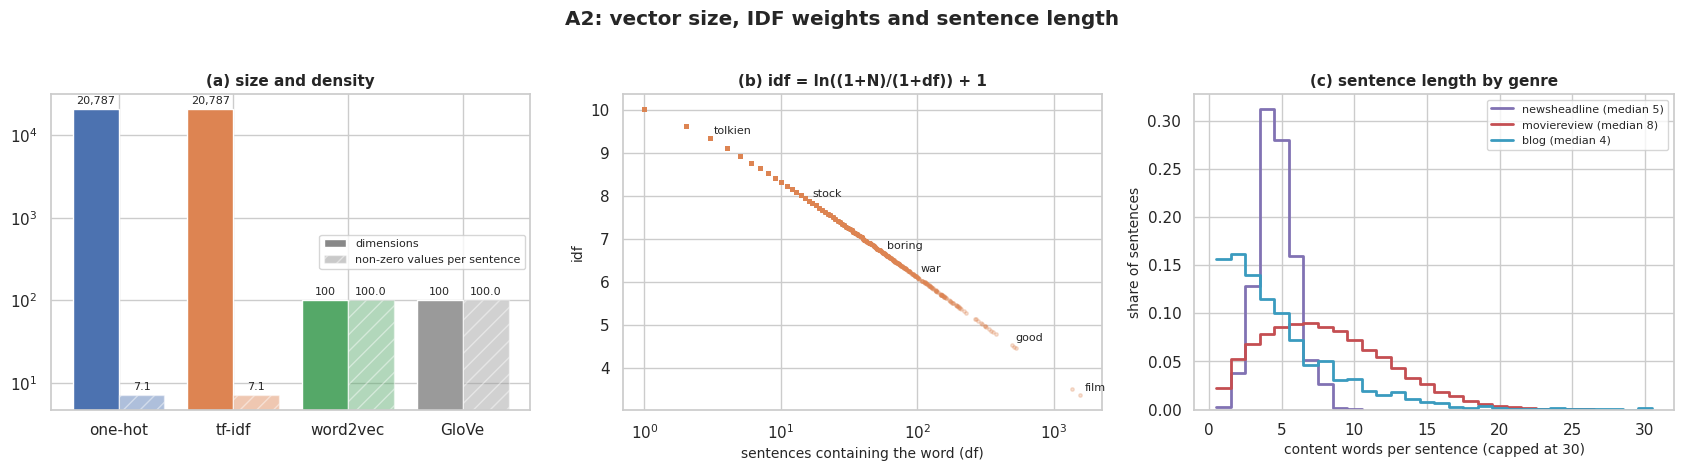

In [8]:
from matplotlib.patches import Patch
fig, ax = plt.subplots(1, 3, figsize=(17, 4.6))
dims = [X_oh.shape[1], X_tf.shape[1], 100, 100]
nnz = [X_oh.getnnz(axis=1).mean(), X_tf.getnnz(axis=1).mean(), 100, 100]
x = np.arange(4)
ax[0].bar(x - 0.2, dims, 0.4, color=[MC[m] for m in ALL_M])
ax[0].bar(x + 0.2, nnz, 0.4, color=[MC[m] for m in ALL_M], alpha=0.45, hatch="//")
ax[0].set_yscale("log")
ax[0].set_xticks(x, ["one-hot", "tf-idf", "word2vec", "GloVe"])
for i, (dv, z) in enumerate(zip(dims, nnz)):
    ax[0].text(i - 0.2, dv * 1.15, f"{dv:,}", ha="center", fontsize=8)
    ax[0].text(i + 0.2, z * 1.15, f"{z:.1f}", ha="center", fontsize=8)
ax[0].legend(handles=[Patch(fc="#888888", label="dimensions"),
                      Patch(fc="#888888", alpha=0.45, hatch="//", label="non-zero values per sentence")],
             fontsize=8, loc="center right")
ax[0].set_title("(a) size and density")

dfreq = np.asarray((X_oh > 0).sum(axis=0)).ravel()
idf = TFVEC.idf_
ax[1].scatter(dfreq, idf, s=6, alpha=0.25, color=MC["tf-idf"])
for w in ["film", "good", "war", "boring", "stock", "tolkien"]:
    j = TFVEC.vocabulary_[w]
    ax[1].annotate(w, (dfreq[j], idf[j]), fontsize=8, xytext=(3, 3), textcoords="offset points")
ax[1].set_xscale("log")
ax[1].set_xlabel("sentences containing the word (df)")
ax[1].set_ylabel("idf")
ax[1].set_title("(b) idf = ln((1+N)/(1+df)) + 1")

for g in GENRES:
    sns.histplot(df[df.genre == g].n_tok.clip(upper=30), ax=ax[2], label=f"{g} (median {int(df[df.genre == g].n_tok.median())})",
                 color=GC[g], discrete=True, stat="probability", element="step", fill=False, lw=2)
ax[2].set_xlabel("content words per sentence (capped at 30)")
ax[2].set_ylabel("share of sentences")
ax[2].legend(fontsize=8)
ax[2].set_title("(c) sentence length by genre")
fig.suptitle("A2: vector size, IDF weights and sentence length", fontweight="bold", y=1.02)
fig.tight_layout(); save(fig, "A2_representation_properties"); plt.show()

## B1-B3: how the methods differ
B1 uses a balanced sample of 1,500 sentences (all pairs).

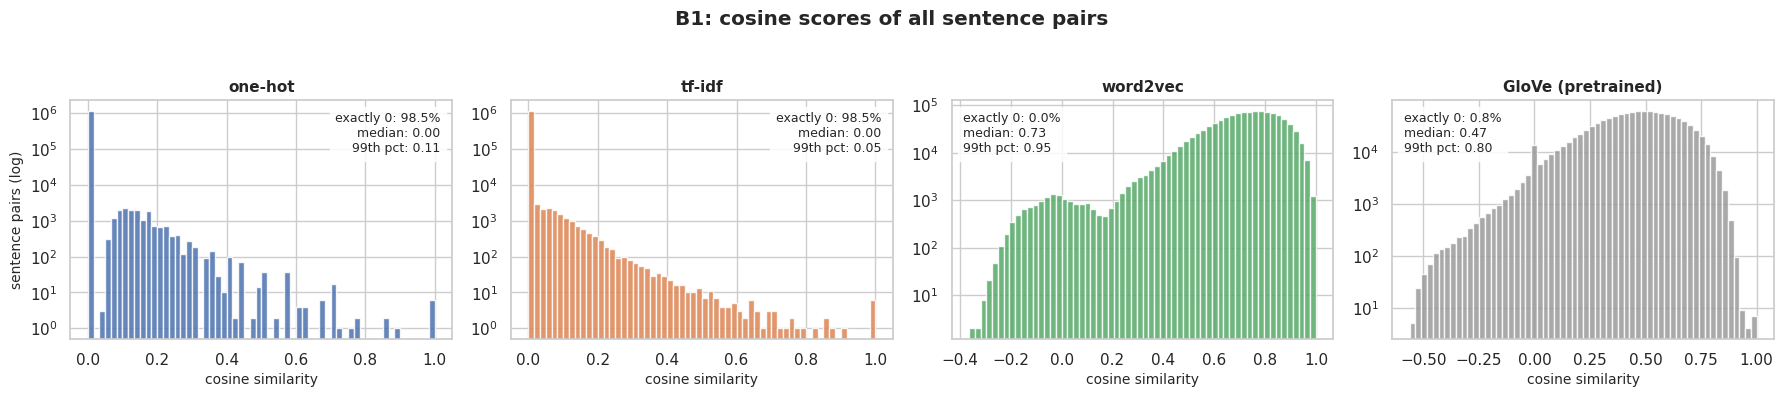

In [9]:
TSNE_S = df.groupby("genre").sample(500, random_state=SEED + 3).index.to_numpy()
iu = np.triu_indices(len(TSNE_S), 1)
fig, ax = plt.subplots(1, 4, figsize=(18, 3.8))
for a, m in zip(ax, ALL_M):
    X = FULL[m][TSNE_S]
    S = X @ X.T
    v = np.asarray(S.toarray() if sparse.issparse(S) else S)[iu]
    a.hist(v, bins=60, color=MC[m], alpha=0.85)
    a.set_yscale("log")
    a.set_title(m)
    a.set_xlabel("cosine similarity")
    xpos, ha = (0.97, "right") if m in ("one-hot", "tf-idf") else (0.03, "left")
    a.text(xpos, 0.95, f"exactly 0: {np.mean(v == 0):.1%}\nmedian: {np.median(v):.2f}\n99th pct: {np.percentile(v, 99):.2f}",
           transform=a.transAxes, ha=ha, va="top", fontsize=9, bbox=dict(fc="white", alpha=0.85))
ax[0].set_ylabel("sentence pairs (log)")
fig.suptitle("B1: cosine scores of all sentence pairs", fontweight="bold", y=1.04)
fig.tight_layout(); save(fig, "B1_pairwise_score_distributions"); plt.show()

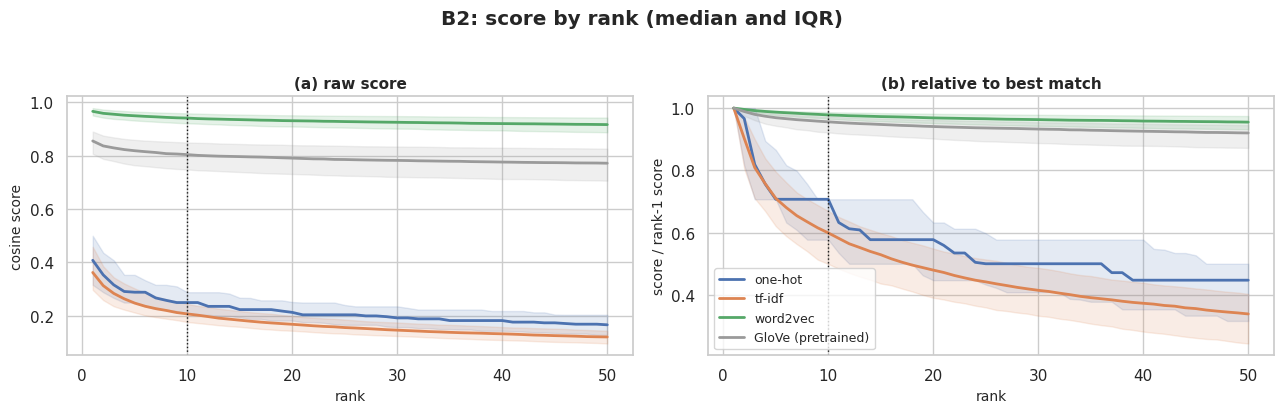

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ranks = np.arange(1, K_MAX + 1)
for m in ALL_M:
    S = RES_FULL[m]["score"]
    for a, M in zip(ax, [S, S / S[:, [0]]]):
        a.plot(ranks, np.median(M, 0), color=MC[m], label=m, lw=2)
        a.fill_between(ranks, np.percentile(M, 25, 0), np.percentile(M, 75, 0), color=MC[m], alpha=0.15)
for a in ax:
    a.axvline(K, color="k", ls=":", lw=1)
    a.set_xlabel("rank")
ax[0].set_ylabel("cosine score")
ax[0].set_title("(a) raw score")
ax[1].set_ylabel("score / rank-1 score")
ax[1].set_title("(b) relative to best match")
ax[1].legend(fontsize=9)
fig.suptitle("B2: score by rank (median and IQR)", fontweight="bold", y=1.03)
fig.tight_layout(); save(fig, "B2_score_decay_by_rank"); plt.show()

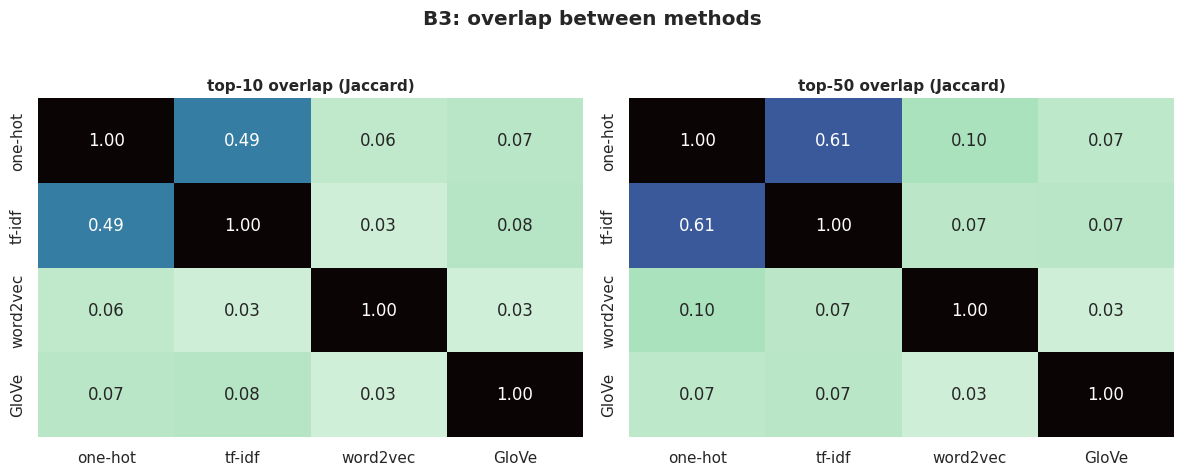

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.6))
short = ["one-hot", "tf-idf", "word2vec", "GloVe"]
for a, k in zip(ax, [10, 50]):
    M = np.zeros((4, 4))
    for i, mi in enumerate(ALL_M):
        for j, mj in enumerate(ALL_M):
            A, B = RES_FULL[mi]["idx"][:, :k], RES_FULL[mj]["idx"][:, :k]
            M[i, j] = np.mean([len(set(x) & set(y)) / len(set(x) | set(y)) for x, y in zip(A, B)])
    sns.heatmap(M, ax=a, annot=True, fmt=".2f", cmap="mako_r", vmin=0, vmax=1, xticklabels=short, yticklabels=short, cbar=False)
    a.set_title(f"top-{k} overlap (Jaccard)")
fig.suptitle("B3: overlap between methods", fontweight="bold", y=1.03)
fig.tight_layout(); save(fig, "B3_method_agreement"); plt.show()

## C3-C6: why results cluster by genre
For C3, silhouette scores are computed on the original vectors (cosine), not on the 2-D map.

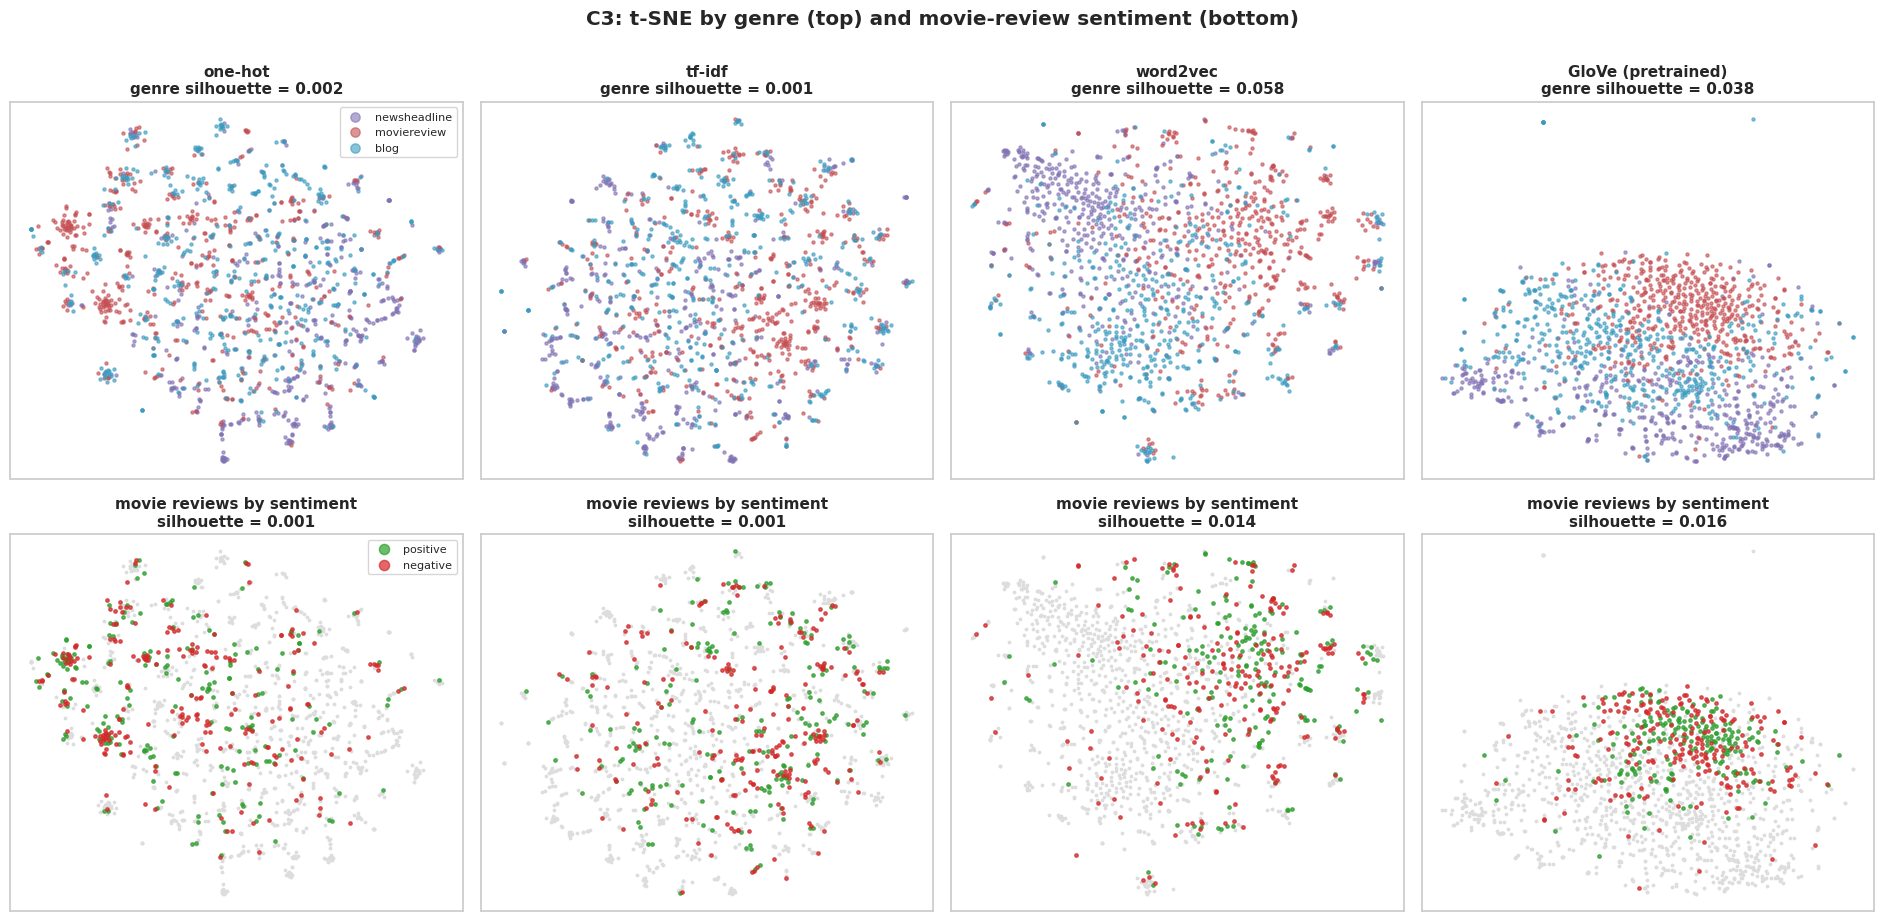

,genre silhouette,sentiment silhouette
one-hot,0.002,0.001
tf-idf,0.001,0.001
word2vec,0.058,0.014
GloVe (pretrained),0.038,0.016


In [12]:
sub = df.loc[TSNE_S].reset_index(drop=True)
mr = (sub.genre == "moviereview") & sub.polarity.isin(["positive", "negative"])
fig, ax = plt.subplots(2, 4, figsize=(19, 9.2))
SIL = {}
for j, m in enumerate(ALL_M):
    X = FULL[m][TSNE_S]
    Z = l2(TruncatedSVD(100, random_state=SEED).fit_transform(X)) if sparse.issparse(X) else X
    emb = TSNE(2, metric="cosine", init="pca", perplexity=40, random_state=SEED).fit_transform(Z)
    SIL[m] = (silhouette_score(X, sub.genre, metric="cosine"),
              silhouette_score(X[mr.to_numpy()], sub.polarity[mr], metric="cosine"))
    for g in GENRES:
        s = (sub.genre == g).to_numpy()
        ax[0, j].scatter(emb[s, 0], emb[s, 1], s=5, alpha=0.6, color=GC[g], label=g)
    ax[0, j].set_title(f"{m}\ngenre silhouette = {SIL[m][0]:.3f}")
    ax[1, j].scatter(emb[:, 0], emb[:, 1], s=3, color="#dddddd")
    for p, c in [("positive", "#2ca02c"), ("negative", "#d62728")]:
        s = (mr & (sub.polarity == p)).to_numpy()
        ax[1, j].scatter(emb[s, 0], emb[s, 1], s=6, alpha=0.7, color=c, label=p)
    ax[1, j].set_title(f"movie reviews by sentiment\nsilhouette = {SIL[m][1]:.3f}")
    for a in ax[:, j]:
        a.set_xticks([])
        a.set_yticks([])
ax[0, 0].legend(markerscale=3, fontsize=8)
ax[1, 0].legend(markerscale=3, fontsize=8)
fig.suptitle("C3: t-SNE by genre (top) and movie-review sentiment (bottom)", fontweight="bold", y=1.0)
fig.tight_layout(); save(fig, "C3_tsne_genre_sentiment"); plt.show()
pd.DataFrame(SIL, index=["genre silhouette", "sentiment silhouette"]).T.round(3)

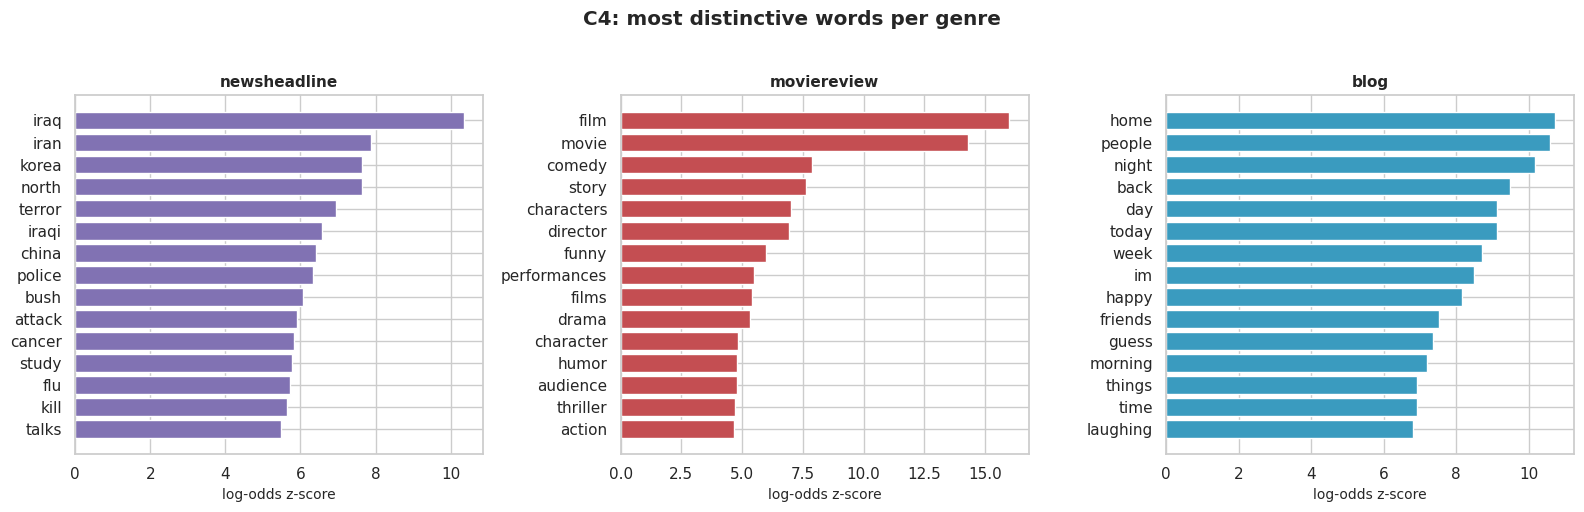

In [13]:
cnt = {g: Counter(t for toks in df[df.genre == g].tokens for t in toks) for g in GENRES}
tot = sum(cnt.values(), Counter())
Ntot = sum(tot.values())
fig, ax = plt.subplots(1, 3, figsize=(16, 5))
for a, g in zip(ax, GENRES):
    yi = cnt[g]
    ni = sum(yi.values())
    nj = Ntot - ni
    a0 = 0.1 * Ntot
    z = {}
    for w, c in tot.items():
        if c < 5:
            continue
        aw = 0.1 * c
        y1, y2 = yi.get(w, 0), c - yi.get(w, 0)
        delta = np.log((y1 + aw) / (ni + a0 - y1 - aw)) - np.log((y2 + aw) / (nj + a0 - y2 - aw))
        z[w] = delta / np.sqrt(1 / (y1 + aw) + 1 / (y2 + aw))
    top = sorted(z.items(), key=lambda kv: -kv[1])[:15][::-1]
    a.barh([w for w, _ in top], [v for _, v in top], color=GC[g])
    a.set_title(g)
    a.set_xlabel("log-odds z-score")
fig.suptitle("C4: most distinctive words per genre", fontweight="bold", y=1.02)
fig.tight_layout(); save(fig, "C4_distinctive_words"); plt.show()

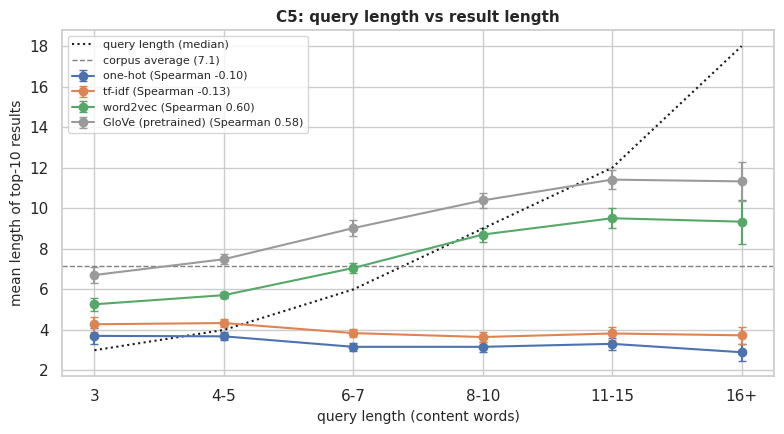

In [14]:
labs = ["3", "4-5", "6-7", "8-10", "11-15", "16+"]
PQ_FULL["len_bin"] = pd.cut(PQ_FULL.q_len, [2, 3, 5, 7, 10, 15, 100], labels=labs)
fig, ax = plt.subplots(figsize=(8, 4.5))
for m in ALL_M:
    d = PQ_FULL[PQ_FULL.method == m]
    agg = d.groupby("len_bin", observed=True).ret_len.agg(["mean", "sem"])
    rho = stats.spearmanr(d.q_len, d.ret_len)[0]
    ax.errorbar(range(len(agg)), agg["mean"], yerr=1.96 * agg["sem"], color=MC[m], marker="o", capsize=3,
                label=f"{m} (Spearman {rho:.2f})")
qmed = PQ_FULL[PQ_FULL.method == "one-hot"].groupby("len_bin", observed=True).q_len.median()
ax.plot(range(len(qmed)), qmed, "k:", label="query length (median)")
ax.axhline(df.n_tok.mean(), color="grey", ls="--", lw=1, label=f"corpus average ({df.n_tok.mean():.1f})")
ax.set_xticks(range(len(labs)), labs)
ax.set_xlabel("query length (content words)")
ax.set_ylabel("mean length of top-10 results")
ax.legend(fontsize=8)
ax.set_title("C5: query length vs result length")
fig.tight_layout(); save(fig, "C5_length_confound"); plt.show()

C6 uses the 300 sentences from the main notebook's sample. Colour = percentile of the similarity within each panel. Bottom row: mean percentile per genre block (0.5 = no structure).

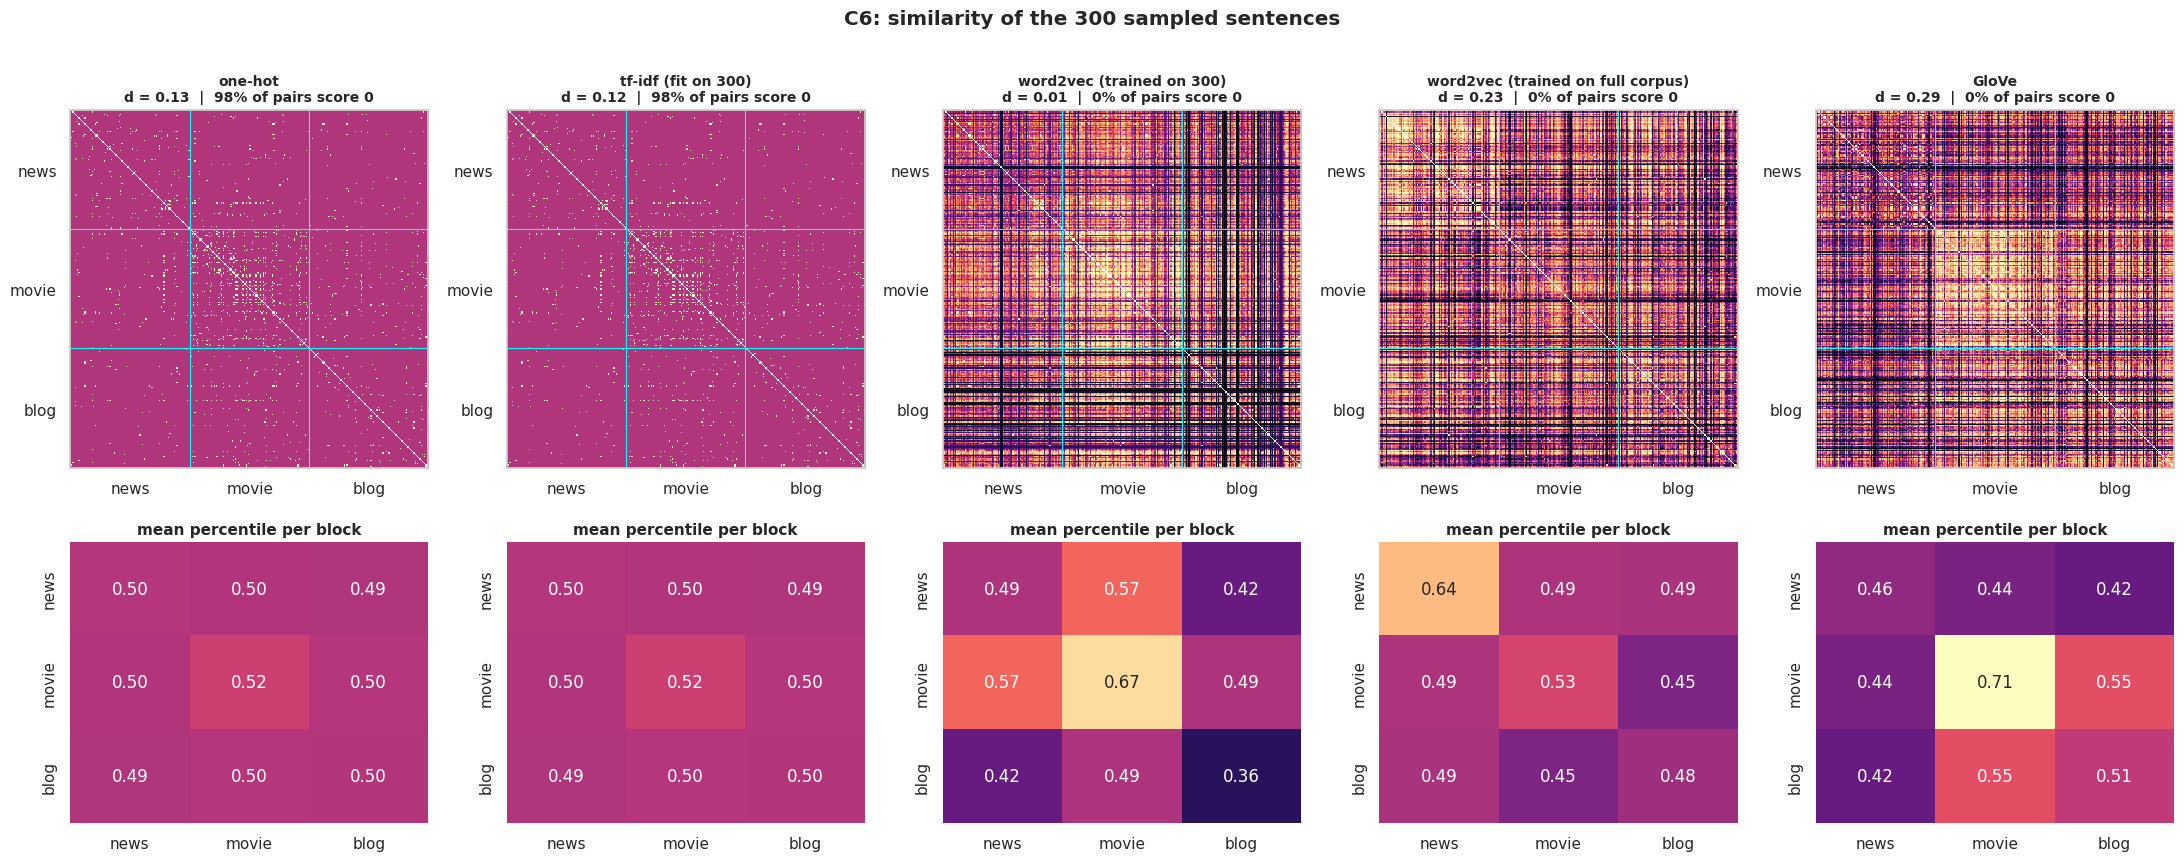

In [15]:
S300 = sample42.assign(_g=pd.Categorical(sample42.genre, GENRES), _p=pd.Categorical(sample42.polarity, P_LIST)).sort_values(["_g", "_p"])
tl300 = S300.tokens.tolist()
panels = {"one-hot": l2(enc_onehot(tl300)), "tf-idf (fit on 300)": l2(enc_tfidf(tl300)[0]),
          "word2vec (trained on 300)": l2(mean_vectors(tl300, train_w2v(tl300).wv)),
          "word2vec (trained on full corpus)": FULL["word2vec"][S300.index.to_numpy()],
          "GloVe": FULL[REF][S300.index.to_numpy()]}
gcode = pd.Categorical(S300.genre, GENRES).codes
same = gcode[:, None] == gcode[None, :]
off = ~np.eye(300, dtype=bool)
labs = ["news", "movie", "blog"]
fig, ax = plt.subplots(2, 5, figsize=(22, 8.6), gridspec_kw={"height_ratios": [1.6, 1]})
for j, (name, X) in enumerate(panels.items()):
    S = X @ X.T
    S = S.toarray() if sparse.issparse(S) else np.asarray(S)
    v = S[off]
    d = (S[same & off].mean() - S[~same].mean()) / v.std()
    P = np.full(S.shape, np.nan)
    P[off] = (stats.rankdata(v) - 0.5) / len(v)
    ax[0, j].imshow(P, cmap="magma", vmin=0, vmax=1, interpolation="nearest")
    ax[0, j].grid(False)
    for b in [100, 200]:
        ax[0, j].axhline(b - 0.5, color="cyan", lw=0.8)
        ax[0, j].axvline(b - 0.5, color="cyan", lw=0.8)
    ax[0, j].set_xticks([50, 150, 250], labs)
    ax[0, j].set_yticks([50, 150, 250], labs)
    ax[0, j].set_title(f"{name}\nd = {d:.2f}  |  {np.mean(v == 0):.0%} of pairs score 0", fontsize=10)
    B = np.array([[np.nanmean(P[np.ix_(gcode == a, gcode == b)]) for b in range(3)] for a in range(3)])
    sns.heatmap(B, ax=ax[1, j], annot=True, fmt=".2f", cmap="magma", vmin=0.3, vmax=0.7, cbar=False,
                xticklabels=labs, yticklabels=labs)
    ax[1, j].set_title("mean percentile per block")
fig.suptitle("C6: similarity of the 300 sampled sentences", fontweight="bold", y=1.0)
fig.tight_layout(); save(fig, "C6_similarity_matrices_300"); plt.show()

## D1, D2: semantic checks
D1(a) and (c) are adjusted for genre: 1.0 means no better than the genres of the results alone would give. D1(b) chance is about 0.5.

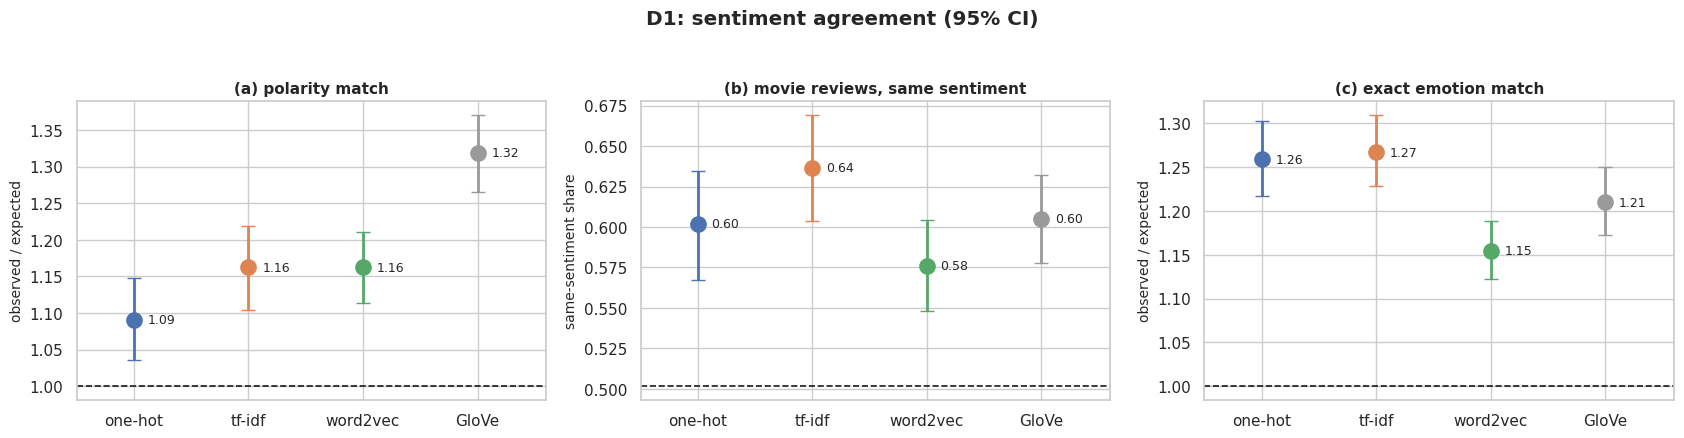

In [16]:
pol = PQ_FULL[PQ_FULL.q_pol.isin(["positive", "negative"])]
mrq = pol[pol.q_genre == "moviereview"]
fig, ax = plt.subplots(1, 3, figsize=(17, 4.2))
specs = [(ax[0], lambda d: boot_ratio(d.pol_obs, d.pol_exp), pol, 1.0, "observed / expected", "(a) polarity match"),
         (ax[1], lambda d: boot_ratio(d.mr_same, d.mr_n), mrq, MR_CHANCE, "same-sentiment share", "(b) movie reviews, same sentiment"),
         (ax[2], lambda d: boot_ratio(d.emo_obs, d.emo_exp), PQ_FULL, 1.0, "observed / expected", "(c) exact emotion match")]
for a, f, data, ref, ylab, title in specs:
    for i, m in enumerate(ALL_M):
        mu, lo, hi = f(data[data.method == m])
        a.errorbar(i, mu, yerr=[[mu - lo], [hi - mu]], fmt="o", ms=11, color=MC[m], capsize=5, lw=2)
        a.text(i + 0.12, mu, f"{mu:.2f}", va="center", fontsize=9)
    a.axhline(ref, color="k", ls="--", lw=1.2)
    a.set_xticks(range(4), ["one-hot", "tf-idf", "word2vec", "GloVe"])
    a.set_xlim(-0.5, 3.6)
    a.set_ylabel(ylab)
    a.set_title(title)
fig.suptitle("D1: sentiment agreement (95% CI)", fontweight="bold", y=1.04)
fig.tight_layout(); save(fig, "D1_sentiment_agreement"); plt.show()

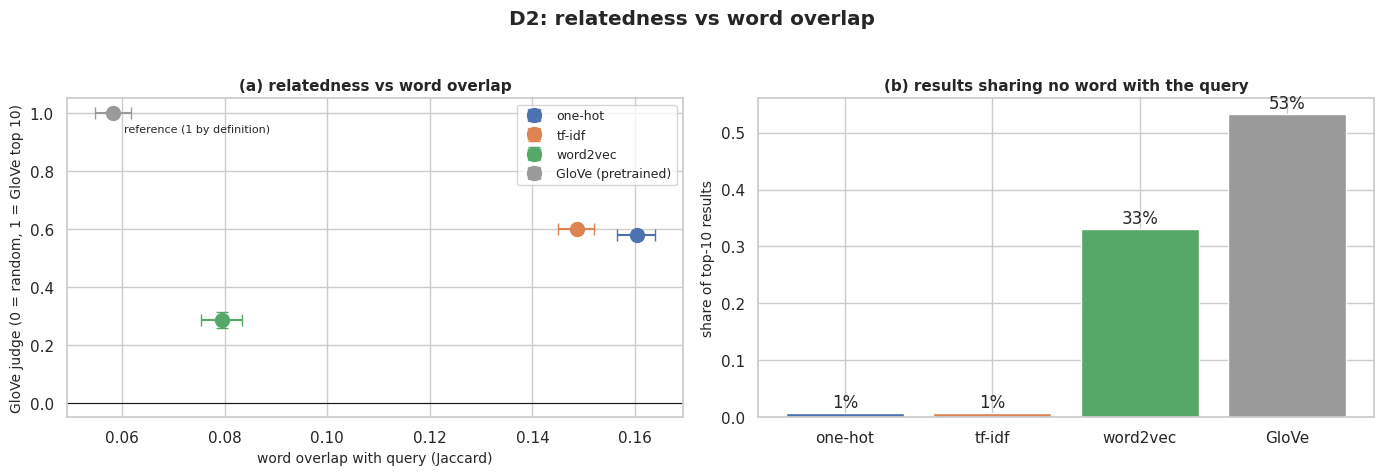

In [17]:
NJ = norm_judge(PQ_FULL)
fig, ax = plt.subplots(1, 2, figsize=(14, 4.6))
for m in ALL_M:
    d = PQ_FULL[PQ_FULL.method == m]
    jx, jlo, jhi = boot_mean(d.jaccard)
    y, ylo, yhi = NJ[m]
    ax[0].errorbar(jx, y, xerr=[[jx - jlo], [jhi - jx]], yerr=[[y - ylo], [yhi - y]], fmt="o", ms=10, color=MC[m], capsize=4, label=m)
ax[0].annotate("reference (1 by definition)", (boot_mean(PQ_FULL[PQ_FULL.method == REF].jaccard)[0], 1),
               xytext=(8, -14), textcoords="offset points", fontsize=8)
ax[0].set_xlabel("word overlap with query (Jaccard)")
ax[0].set_ylabel("GloVe judge (0 = random, 1 = GloVe top 10)")
ax[0].set_title("(a) relatedness vs word overlap")
ax[0].legend(fontsize=9)
ax[0].axhline(0, color="k", lw=0.8)
shares = [PQ_FULL[PQ_FULL.method == m].no_shared_word.mean() for m in ALL_M]
ax[1].bar(range(4), shares, color=[MC[m] for m in ALL_M])
for i, s in enumerate(shares):
    ax[1].text(i, s + 0.01, f"{s:.0%}", ha="center")
ax[1].set_xticks(range(4), ["one-hot", "tf-idf", "word2vec", "GloVe"])
ax[1].set_ylabel("share of top-10 results")
ax[1].set_title("(b) results sharing no word with the query")
fig.suptitle("D2: relatedness vs word overlap", fontweight="bold", y=1.03)
fig.tight_layout(); save(fig, "D2_lexical_vs_semantic"); plt.show()

## F1-F4: reliability
F1: dashed lines are the full-corpus values. Relatedness in (c) is scaled within each 100-sentence pool.

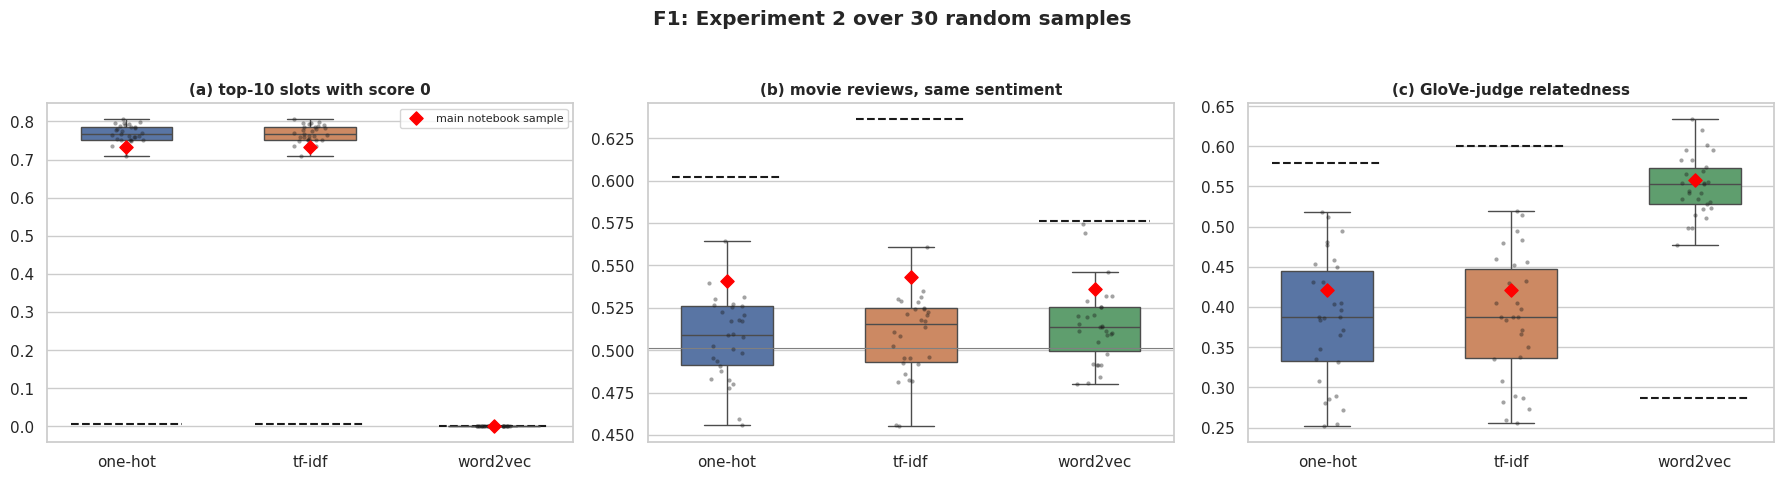

In [18]:
sep = REP[REP.setting == "100/genre (separate)"]
full_s = summarize(PQ_FULL)
fig, ax = plt.subplots(1, 3, figsize=(18, 4.6))
for a, (col, title) in zip(ax, [("zero_slots", "(a) top-10 slots with score 0"),
                                 ("mr_sentiment", "(b) movie reviews, same sentiment"),
                                 ("norm_judge", "(c) GloVe-judge relatedness")]):
    sns.boxplot(data=sep, x="method", y=col, order=METHODS, palette=MC, ax=a, width=0.5, fliersize=0)
    sns.stripplot(data=sep[~sep.your_sample], x="method", y=col, order=METHODS, color="k", size=3, alpha=0.4, ax=a)
    y = sep[sep.your_sample].set_index("method").reindex(METHODS)[col]
    a.scatter(range(3), y, marker="D", color="red", s=45, zorder=5, label="main notebook sample")
    for i, m in enumerate(METHODS):
        a.hlines(full_s.loc[m, col], i - 0.3, i + 0.3, color="k", ls="--", lw=1.5)
    a.set_title(title)
    a.set_xlabel("")
    a.set_ylabel("")
ax[1].axhline(MR_CHANCE, color="grey", lw=0.8)
ax[0].legend(fontsize=8)
fig.suptitle(f"F1: Experiment 2 over {N_REPEATS} random samples", fontweight="bold", y=1.04)
fig.tight_layout(); save(fig, "F1_repeated_sampling"); plt.show()

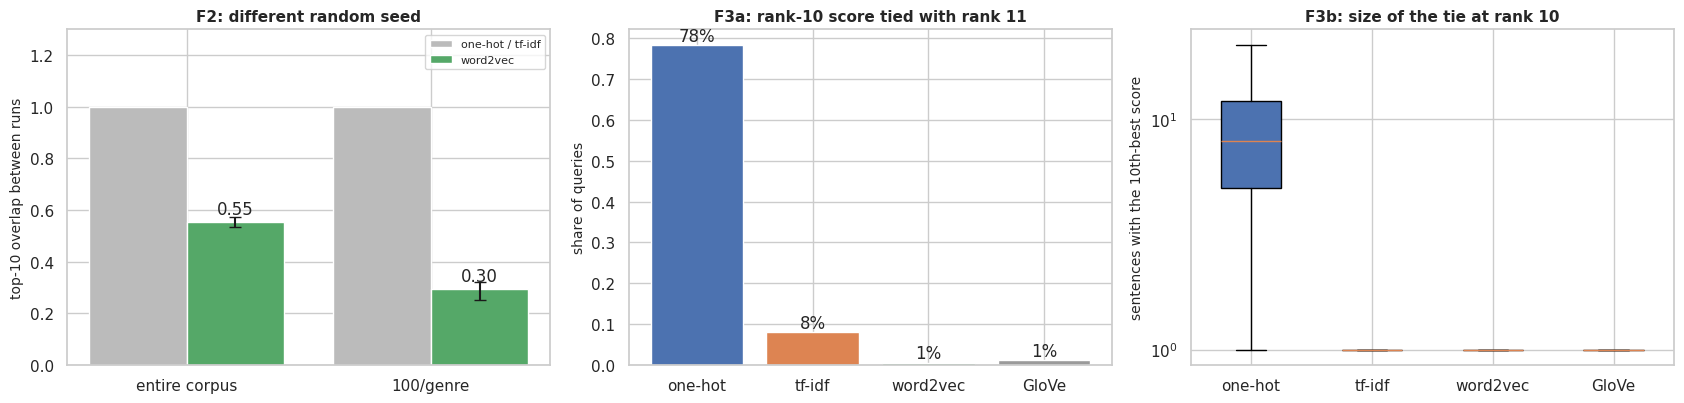

In [19]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4.2))
stab = SEED_STAB.groupby("setting").jaccard.agg(["mean", "min", "max"]).reindex(["entire corpus", "100/genre"])
xs = np.arange(2)
ax[0].bar(xs - 0.2, [1, 1], 0.4, color="#bbbbbb", label="one-hot / tf-idf")
ax[0].bar(xs + 0.2, stab["mean"], 0.4, color=MC["word2vec"],
          yerr=[stab["mean"] - stab["min"], stab["max"] - stab["mean"]], capsize=4, label="word2vec")
for i, v in enumerate(stab["mean"]):
    ax[0].text(i + 0.2, v + 0.03, f"{v:.2f}", ha="center")
ax[0].set_xticks(xs, stab.index)
ax[0].set_ylim(0, 1.3)
ax[0].set_ylabel("top-10 overlap between runs")
ax[0].set_title("F2: different random seed")
ax[0].legend(fontsize=8, loc="upper right")
tie = PQ_FULL.groupby("method").boundary_tie.mean().reindex(ALL_M)
ax[1].bar(range(4), tie, color=[MC[m] for m in ALL_M])
for i, v in enumerate(tie):
    ax[1].text(i, v + 0.01, f"{v:.0%}", ha="center")
ax[1].set_xticks(range(4), ["one-hot", "tf-idf", "word2vec", "GloVe"])
ax[1].set_ylabel("share of queries")
ax[1].set_title("F3a: rank-10 score tied with rank 11")
for i, m in enumerate(ALL_M):
    ax[2].boxplot(PQ_FULL[PQ_FULL.method == m].tied_at_k, positions=[i], widths=0.5, patch_artist=True,
                  boxprops=dict(facecolor=MC[m]), showfliers=False)
ax[2].set_yscale("log")
ax[2].set_xticks(range(4), ["one-hot", "tf-idf", "word2vec", "GloVe"])
ax[2].set_ylabel("sentences with the 10th-best score")
ax[2].set_title("F3b: size of the tie at rank 10")
fig.tight_layout(); save(fig, "F2_F3_stability_and_ties"); plt.show()

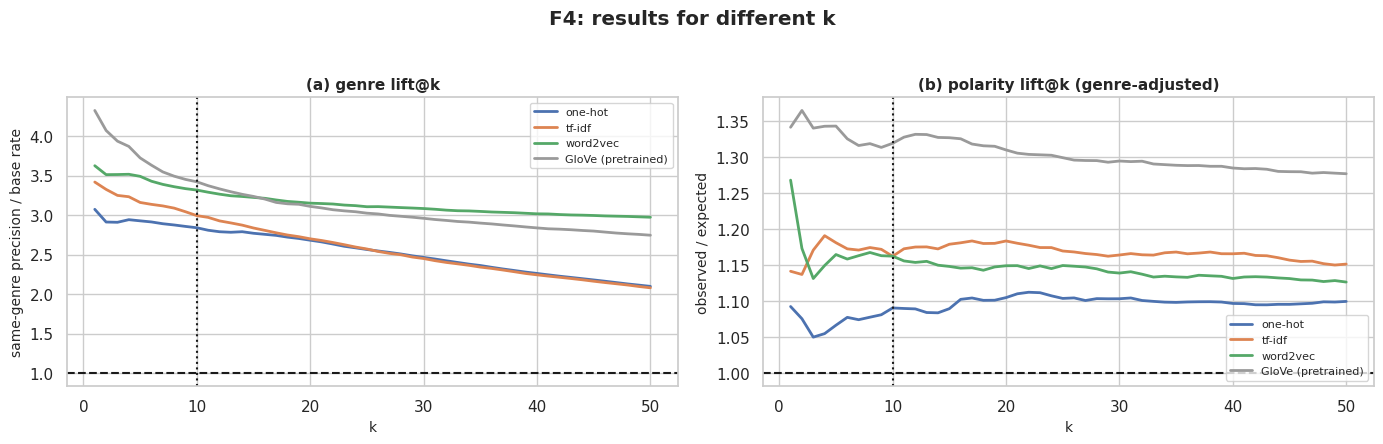

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.3))
ks = np.arange(1, K_MAX + 1)
gq = META_FULL["g"][EVAL_Q]
pq = META_FULL["p"][EVAL_Q]
polmask = np.isin(pq, [POS, NEG])
base = GENRE_BASE.to_numpy()[gq]
for m in ALL_M:
    top = RES_FULL[m]["idx"]
    gt = META_FULL["g"][top]
    same = (gt == gq[:, None]).cumsum(1) / ks
    ax[0].plot(ks, (same / base[:, None]).mean(0), color=MC[m], lw=2, label=m)
    obs = (META_FULL["p"][top] == pq[:, None])[polmask].cumsum(1).sum(0)
    exp = COND_POL[gt, pq[:, None]][polmask].cumsum(1).sum(0)
    ax[1].plot(ks, obs / exp, color=MC[m], lw=2, label=m)
ax[0].set_ylabel("same-genre precision / base rate")
ax[0].set_title("(a) genre lift@k")
ax[1].set_ylabel("observed / expected")
ax[1].set_title("(b) polarity lift@k (genre-adjusted)")
for a in ax:
    a.axhline(1, color="k", ls="--")
    a.axvline(K, color="k", ls=":")
    a.set_xlabel("k")
    a.legend(fontsize=8)
fig.suptitle("F4: results for different k", fontweight="bold", y=1.03)
fig.tight_layout(); save(fig, "F4_k_sensitivity"); plt.show()

## T1: summary table
95% bootstrap CIs over the 908 queries, and paired Wilcoxon tests (Holm-corrected) between the three methods.

In [21]:
def fmt(t):
    # "mean [low, high]"
    return f"{t[0]:.3f} [{t[1]:.3f}, {t[2]:.3f}]"

rows = {}
for m in ALL_M:
    d = PQ_FULL[PQ_FULL.method == m]
    dp = d[d.q_pol.isin(["positive", "negative"])]
    dm = dp[dp.q_genre == "moviereview"]
    rows[m] = {"same-genre@10": fmt(boot_mean(d.same_genre)),
               "genre lift@10": fmt(boot_mean(d.same_genre / GENRE_BASE.reindex(d.q_genre).to_numpy())),
               "polarity lift (genre-adj.)": fmt(boot_ratio(dp.pol_obs, dp.pol_exp)),
               "movie-review sentiment agreement": fmt(boot_ratio(dm.mr_same, dm.mr_n)),
               "emotion lift (genre-adj.)": fmt(boot_ratio(d.emo_obs, d.emo_exp)),
               "word overlap (Jaccard)": fmt(boot_mean(d.jaccard)),
               "results sharing no word": fmt(boot_mean(d.no_shared_word)),
               "GloVe-judge relatedness": fmt(NJ[m]) if m != REF else "1 (reference)",
               "rank-10 tie rate": fmt(boot_mean(d.boundary_tie.astype(float)))}
T1 = pd.DataFrame(rows)
T1.to_csv(FIG_DIR / "T1_summary_table.csv")
T1

,one-hot,tf-idf,word2vec,GloVe (pretrained)
same-genre@10,"0.571 [0.552, 0.591]","0.577 [0.560, 0.594]","0.622 [0.602, 0.644]","0.662 [0.640, 0.683]"
genre lift@10,"2.839 [2.656, 3.017]","2.992 [2.816, 3.168]","3.316 [3.096, 3.525]","3.420 [3.192, 3.641]"
polarity lift (genre-adj.),"1.090 [1.036, 1.148]","1.162 [1.105, 1.219]","1.162 [1.114, 1.211]","1.319 [1.265, 1.371]"
movie-review sentiment agreement,"0.602 [0.567, 0.635]","0.636 [0.604, 0.669]","0.576 [0.548, 0.604]","0.605 [0.577, 0.632]"
emotion lift (genre-adj.),"1.259 [1.217, 1.303]","1.267 [1.228, 1.310]","1.155 [1.123, 1.189]","1.210 [1.173, 1.251]"
word overlap (Jaccard),"0.160 [0.156, 0.164]","0.149 [0.145, 0.152]","0.079 [0.075, 0.083]","0.058 [0.055, 0.062]"
results sharing no word,"0.007 [0.003, 0.011]","0.007 [0.003, 0.011]","0.331 [0.306, 0.355]","0.533 [0.516, 0.552]"
GloVe-judge relatedness,"0.579 [0.566, 0.591]","0.600 [0.587, 0.612]","0.286 [0.259, 0.312]",1 (reference)
rank-10 tie rate,"0.783 [0.757, 0.808]","0.080 [0.064, 0.099]","0.006 [0.001, 0.011]","0.012 [0.006, 0.020]"


In [22]:
PQ_FULL["pol_prec"] = np.where(PQ_FULL.q_pol.isin(["positive", "negative"]), PQ_FULL.pol_obs / K, np.nan)
tests = []
for metric in ["same_genre", "pol_prec", "jaccard", "judge"]:
    piv = PQ_FULL.pivot_table(index="q", columns="method", values=metric).dropna()
    res = []
    for a, b in itertools.combinations(METHODS, 2):
        diff = piv[a] - piv[b]
        p = stats.wilcoxon(piv[a], piv[b], zero_method="zsplit")[1] if diff.abs().sum() > 0 else 1.0
        res.append([metric, f"{a} vs {b}", diff.mean(), p, len(piv)])
    ps = np.array([r[3] for r in res])
    adj = np.empty(3)
    running = 0
    for rank, i in enumerate(np.argsort(ps)):
        running = max(running, min(1, ps[i] * (3 - rank)))
        adj[i] = running
    tests += [r + [pa] for r, pa in zip(res, adj)]
TESTS = pd.DataFrame(tests, columns=["metric", "comparison", "mean difference", "p", "n queries", "p (Holm)"])
TESTS.to_csv(FIG_DIR / "T1_paired_tests.csv", index=False)
TESTS.round(4)

,metric,comparison,mean difference,p,n queries,p (Holm)
0,same_genre,one-hot vs tf-idf,-0.0057,0.2633,908,0.2633
1,same_genre,one-hot vs word2vec,-0.0503,0.0000,908,0.0000
2,same_genre,tf-idf vs word2vec,-0.0446,0.0000,908,0.0000
3,pol_prec,one-hot vs tf-idf,-0.0031,0.8388,477,0.8388
4,pol_prec,one-hot vs word2vec,-0.0226,0.0574,477,0.1723
5,pol_prec,tf-idf vs word2vec,-0.0195,0.1088,477,0.2176
6,jaccard,one-hot vs tf-idf,0.0117,0.0000,908,0.0000
7,jaccard,one-hot vs word2vec,0.0808,0.0000,908,0.0000
8,jaccard,tf-idf vs word2vec,0.0692,0.0000,908,0.0000
9,judge,one-hot vs tf-idf,-0.0064,0.0000,908,0.0000
